In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import Ridge

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


In [2]:
data=load_diabetes()

# IO
X=data.data
y=data.target

# TTS
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

# train LR
lr=LinearRegression()
lr.fit(X_train,y_train)

print(lr.coef_)
print(lr.intercept_)

y_pred=lr.predict(X_test)

print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496
R2 score 0.5188113124539249
RMSE 48.72713760953252


In [3]:
# Apply Ridge Regreesion

# Alpha -> Lambda Value
# Strategy -> Hit and trial method , Cross Validation, Grid Search CV -> To get Perfect alpha Value

rr=Ridge(alpha=1) # Default value alpha -> 1

rr.fit(X_train,y_train)

print(rr.coef_)
print(rr.intercept_)

y_pred1=rr.predict(X_test)   

print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

[ 4.29550980e+01 -6.78870674e+01  2.80270383e+02  1.95506087e+02
  1.50362795e-02 -3.08131261e+01 -1.45767246e+02  1.14715808e+02
  2.43273028e+02  1.20912940e+02]
152.1356034114563
R2 score 0.45671008338777075
RMSE 51.77606230385884


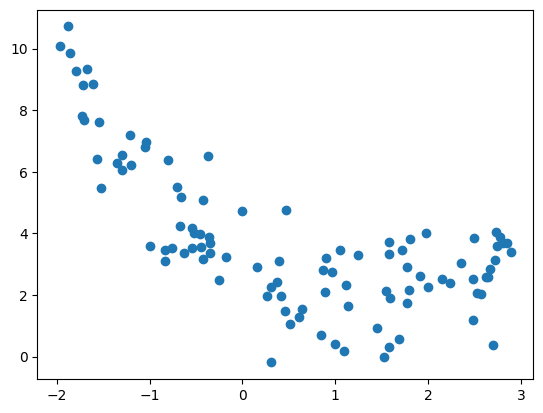

In [4]:
# Generate Polynomial (Non convex Data)
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show() 

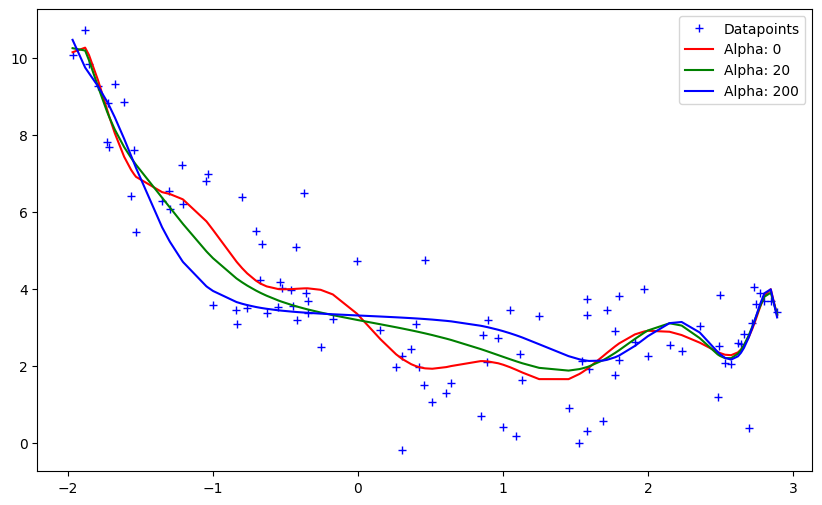

In [ ]:
# Solve Via Ridge Regreesion (Rather Than Linear Regreesion)

# Generate Over Fitting Model -> Degree 16 on Degree 2 Equation
def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

# Different Alpha Value 
# 0 -> Behave like Linear Reg
alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

# Observation -> 
# 0 -> Like LR -> OverFitted Model
# 20 -> Trying To Reduce the Effect of Over Fitting
# 200 -> Under Fitting (Over Simplifying) -> Under Fitting